In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv(r"C:\Users\Deepika\OneDrive\Desktop\Tableau_ Learning\Most_Streamed_Artist_On_Spotify.csv")

In [3]:
df.head()

,Artist Name,Sex,Country of Origin,Primary Language,Primary Genre,Artist Type,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams
0,Drake,Male,Canada,English,Hip-Hop,Solo,2006,137492.1,94851.1,42640.9,53323.9,38.783246,84168.2,61.216754
1,Taylor Swift,Female,United States,English,Pop,Solo,2006,127861.0,126177.3,1683.8,113421.5,88.706877,14439.5,11.293123
2,Bad Bunny,Male,United States,Spanish,Reggaeton,Solo,2013,125899.8,82189.3,43710.5,48887.0,38.830086,77012.8,61.169914
3,The Weeknd,Male,Canada,English,R&B,Solo,2009,95703.2,77189.4,18513.8,51020.0,53.310652,44683.2,46.689348
4,Justin Bieber,Male,Canada,English,Pop,Solo,2009,78104.4,48316.2,29788.2,29638.3,37.947030,48466.1,62.052970


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Artist Name                          500 non-null    object 
 1   Sex                                  500 non-null    object 
 2   Country of Origin                    500 non-null    object 
 3   Primary Language                     500 non-null    object 
 4   Primary Genre                        500 non-null    object 
 5    Artist Type                         500 non-null    object 
 6   Debut Year                           500 non-null    int64  
 7   Total Streams (in millions)          500 non-null    float64
 8   Lead Streams (in millions)           500 non-null    float64
 9   Feature Streams (in millions)        500 non-null    float64
 10  Solo Streams (in millions)           500 non-null    float64
 11  % of Solo Streams               

In [5]:
df.shape

(500, 14)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Debut Year,500.0,2005.346000,13.312578,1939.0,2001.750000,2009.000000,2014.000000,2023.0
Total Streams (in millions),500.0,16817.610200,14845.197632,6972.0,8768.175000,11923.250000,18020.050000,137492.1
Lead Streams (in millions),500.0,12141.734000,11844.675186,0.0,6489.750000,8716.350000,13456.900000,126177.3
Feature Streams (in millions),500.0,4681.289000,5952.827762,0.0,696.500000,3005.600000,6093.350000,43710.5
Solo Streams (in millions),500.0,8324.397600,9589.010168,0.0,2519.775000,6472.950000,10115.550000,113421.5
% of Solo Streams,500.0,50.613084,33.762147,0.0,20.117951,47.062829,83.139781,100.0
Collaborative Streams (in millions),500.0,8493.212600,9612.491536,0.0,2015.650000,6592.250000,11019.575000,84168.2
% of Collaborative Streams,500.0,49.386916,33.762147,0.0,16.860219,52.937171,79.882049,100.0


In [8]:
df.isnull().sum()

Artist Name                            0
Sex                                    0
Country of Origin                      0
Primary Language                       0
Primary Genre                          0
 Artist Type                           0
Debut Year                             0
Total Streams (in millions)            0
Lead Streams (in millions)             0
Feature Streams (in millions)          0
Solo Streams (in millions)             0
% of Solo Streams                      0
Collaborative Streams (in millions)    0
% of Collaborative Streams             0
dtype: int64

In [10]:
duplicates = df[df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [Artist Name, Sex, Country of Origin, Primary Language, Primary Genre,  Artist Type, Debut Year, Total Streams (in millions), Lead Streams (in millions), Feature Streams (in millions), Solo Streams (in millions), % of Solo Streams, Collaborative Streams (in millions), % of Collaborative Streams]
Index: []


In [11]:
Q1 = df["Total Streams (in millions)"].quantile(0.25)
Q3 = df["Total Streams (in millions)"].quantile(0.75)

IQR = Q3 - Q1

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")

Q1: 8768.175
Q3: 18020.05
IQR: 9251.875


In [12]:
correlation = df["Total Streams (in millions)"].corr(df["Lead Streams (in millions)"])

print(correlation)

0.9248544449671747


In [14]:
artist_type_analysis = (
    df.groupby(" Artist Type")["Total Streams (in millions)"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

print(artist_type_analysis)

              count          mean   median
 Artist Type                              
Solo            373  18018.654692  12700.7
Group           127  13290.133071  10607.0


In [19]:
genre_analysis = ( df.groupby ("Primary Genre")["Total Streams (in millions)"]
                  .agg(["count", "mean", "median"])
                  .sort_values("median", ascending = False)
                      )
print(genre_analysis)

                  count          mean    median
Primary Genre                                  
Spoken Word           1  24607.000000  24607.00
Reggae                2  16598.000000  16598.00
EDM                  22  16686.222727  14694.90
Hip-Hop             115  18487.435652  13692.00
Alternative           9  16469.700000  13287.00
R&B                  31  18409.625806  13065.70
Reggaeton            43  20671.048837  12929.70
Pop                 102  19643.154902  12649.15
Regional Mexican     19  13474.394737  12151.30
Filmi                11  13759.809091  11014.90
Sertanjeo             9  11644.266667  10914.20
Afrobeats             2  10719.800000  10719.80
Rock                 60  13534.710000  10656.35
Bachata               3  13550.466667  10607.00
Soundtrack            3  13730.433333  10048.30
Latin                30  12598.733333   9858.30
Country              10  13028.620000   9541.40
Folk                  4   9841.700000   8879.15
K-Pop                11  14303.518182   

Skew (raw): 3.9978540671347313
Skew (log1p): 1.2241582339490167


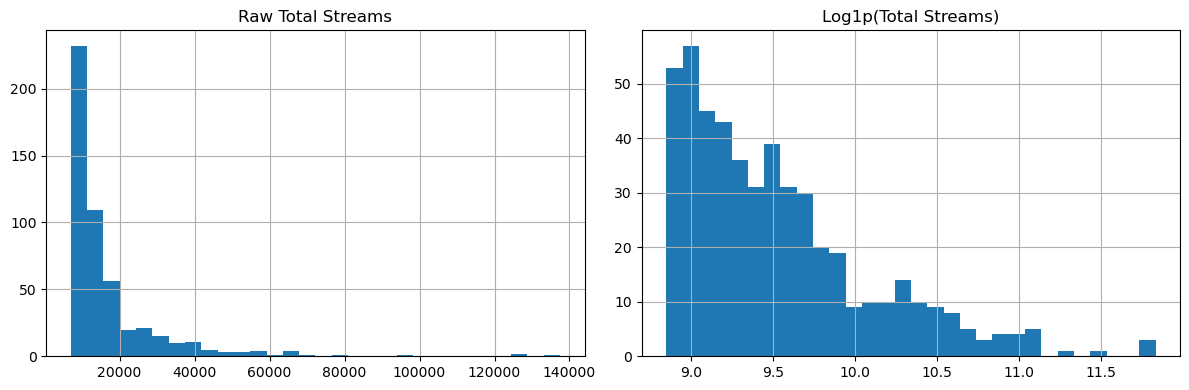

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Raw target skew
print("Skew (raw):", df["Total Streams (in millions)"].skew())

# Log-transformed target
log_streams = np.log1p(df["Total Streams (in millions)"])
print("Skew (log1p):", log_streams.skew())

# Side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["Total Streams (in millions)"].hist(bins=30, ax=axes[0])
axes[0].set_title("Raw Total Streams")

log_streams.hist(bins=30, ax=axes[1])
axes[1].set_title("Log1p(Total Streams)")

plt.tight_layout()
plt.show()

In [21]:
# Check category frequencies
print(df["Country of Origin"].value_counts())
print(df["Primary Genre"].value_counts())


# Function to bucket rare categories
def bucket_categories(series, threshold=5):
    counts = series.value_counts()
    return series.apply(lambda x: x if counts[x] >= threshold else "Other")


# Apply bucketing to Country and Genre
df["Country_Bucketed"] = bucket_categories(df["Country of Origin"], threshold=5)
df["Genre_Bucketed"] = bucket_categories(df["Primary Genre"], threshold=5)


# Verify the new categories
print(df["Country_Bucketed"].value_counts())
print(df["Genre_Bucketed"].value_counts())

Country of Origin
United States          265
United Kingdom          55
Mexico                  27
Canada                  18
Colombia                16
Brazil                  15
India                   13
South Korea             11
Argentina                9
Australia                7
Germany                  7
Spain                    6
Sweden                   5
France                   5
Ireland                  4
Italy                    3
Norway                   2
Scotland                 2
Dominican Republic       2
Japan                    2
Nigeria                  2
Netherlands              2
Jamaica                  2
Cuba                     1
Denmark                  1
Philippines              1
Austria                  1
Guatemala                1
Pakistan                 1
Nepal                    1
DR Congo                 1
Belgium                  1
Senegal                  1
Trinidad and Tobago      1
Venezuela                1
South Africa             1
Panama    

In [22]:
# Check language frequencies
print(df["Primary Language"].value_counts())


# Bucket rare languages
df["Language_Bucketed"] = bucket_categories(df["Primary Language"], threshold=5)


# Verify the new categories
print(df["Language_Bucketed"].value_counts())

Primary Language
English       340
Spanish       105
Portuguese     15
Korean         11
Hindi          11
German          7
French          4
Italian         3
Tamil           2
Urdu            1
Punjabi         1
Name: count, dtype: int64
Language_Bucketed
English       340
Spanish       105
Portuguese     15
Korean         11
Hindi          11
Other          11
German          7
Name: count, dtype: int64


In [24]:
import numpy as np
import pandas as pd

# Select categorical features + numeric feature
features = [
    "Country_Bucketed",
    "Genre_Bucketed",
    "Language_Bucketed",
    "Sex",
    " Artist Type",
    "Debut Year"
]

# Create X with one-hot encoding
X = pd.get_dummies(
    df[features],
    drop_first=True
)

# Create target variable with log1p transformation
y = np.log1p(df["Total Streams (in millions)"])

# Check shape and columns
print(X.shape)
print(X.columns)

(500, 38)
Index(['Debut Year', 'Country_Bucketed_Australia', 'Country_Bucketed_Brazil',
       'Country_Bucketed_Canada', 'Country_Bucketed_Colombia',
       'Country_Bucketed_France', 'Country_Bucketed_Germany',
       'Country_Bucketed_India', 'Country_Bucketed_Mexico',
       'Country_Bucketed_Other', 'Country_Bucketed_South Korea',
       'Country_Bucketed_Spain', 'Country_Bucketed_Sweden',
       'Country_Bucketed_United Kingdom', 'Country_Bucketed_United States',
       'Genre_Bucketed_Country', 'Genre_Bucketed_EDM', 'Genre_Bucketed_Filmi',
       'Genre_Bucketed_Hip-Hop', 'Genre_Bucketed_K-Pop',
       'Genre_Bucketed_Latin', 'Genre_Bucketed_Metal', 'Genre_Bucketed_Other',
       'Genre_Bucketed_Pop', 'Genre_Bucketed_R&B', 'Genre_Bucketed_Reggaeton',
       'Genre_Bucketed_Regional Mexican', 'Genre_Bucketed_Rock',
       'Genre_Bucketed_Sertanjeo', 'Language_Bucketed_German',
       'Language_Bucketed_Hindi', 'Language_Bucketed_Korean',
       'Language_Bucketed_Other', 'Languag

In [25]:
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (400, 38)
X_test shape: (100, 38)
y_train shape: (400,)
y_test shape: (100,)


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (400, 38)
X_test_scaled shape: (100, 38)


In [27]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    has_xgb = True
except ImportError:
    has_xgb = False

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42),
    "ElasticNet": ElasticNet(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
}

if has_xgb:
    models["XGBoost"] = XGBRegressor(random_state=42)

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    y_pred_actual = np.expm1(y_pred)
    y_test_actual = np.expm1(y_test)

    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    r2 = r2_score(y_test_actual, y_pred_actual)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
print(results_df)

               Model           MAE          RMSE        R2
0  Gradient Boosting  10681.832315  20049.936873 -0.006835
1                KNN  10671.907216  20225.742912 -0.024569
2              Ridge  10335.153462  20227.634845 -0.024761
3  Linear Regression  10346.846393  20233.247809 -0.025330
4      Random Forest  11298.387458  20338.550424 -0.036030
5              Lasso  10301.234025  20596.891199 -0.062517
6         ElasticNet  10301.234025  20596.891199 -0.062517
7                SVR  10054.811070  20652.192588 -0.068230
8      Decision Tree  15498.153614  27542.939226 -0.899997


In [28]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = np.expm1(dummy.predict(X_test_scaled))
y_test_actual = np.expm1(y_test)

print("Dummy R2:", r2_score(y_test_actual, y_pred_dummy))
print("Dummy MAE:", mean_absolute_error(y_test_actual, y_pred_dummy))

Dummy R2: -0.06251680307720342
Dummy MAE: 10301.234024738997


In [29]:
import pandas as pd

# Random Forest feature importances
rf_model = models["Random Forest"]
rf_importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("=== Random Forest Feature Importances (top 15) ===")
print(rf_importances.head(15))

# Gradient Boosting feature importances
gb_model = models["Gradient Boosting"]
gb_importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gb_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\n=== Gradient Boosting Feature Importances (top 15) ===")
print(gb_importances.head(15))

# Ridge coefficients (didn't zero out like Lasso did)
ridge_model = models["Ridge"]
ridge_coefs = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": ridge_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print("\n=== Ridge Coefficients by |magnitude| (top 15) ===")
print(ridge_coefs.head(15))

=== Random Forest Feature Importances (top 15) ===
                            Feature  Importance
0                        Debut Year    0.470401
35                         Sex_Male    0.052217
14   Country_Bucketed_United States    0.047211
37                 Artist Type_Solo    0.044696
23               Genre_Bucketed_Pop    0.041867
18           Genre_Bucketed_Hip-Hop    0.038947
3           Country_Bucketed_Canada    0.033999
24               Genre_Bucketed_R&B    0.027961
13  Country_Bucketed_United Kingdom    0.024961
4         Country_Bucketed_Colombia    0.021841
25         Genre_Bucketed_Reggaeton    0.019492
9            Country_Bucketed_Other    0.018861
16               Genre_Bucketed_EDM    0.016506
34        Language_Bucketed_Spanish    0.015985
36                        Sex_Mixed    0.011537

=== Gradient Boosting Feature Importances (top 15) ===
                           Feature  Importance
0                       Debut Year    0.484496
37                Artist Type_S

In [ ]:
# #Objective: Predict total Spotify streams from artist demographics (sex, country, language, genre, artist type, debut year), 
# explicitly excluding stream-derived columns identified as leakage (Lead/Feature/Solo/Collaborative Streams and their percentages, 
# which are algebraically derived from the target).
# #Approach: Bucketed rare categories (<5 occurrences) in Country, Genre, and 
# Language to avoid one-hot columns backed by single data points. One-hot encoded (drop_first=True) to 38 features. 
# Log1p-transformed the target to correct severe right skew (3.998 → 1.224). Scaled features for distance/regularization-sensitive 
# models. Ran a 9-model sweep (linear, regularized linear, tree-based, KNN, SVR) with an 80/20 split, scored on MAE/RMSE/R² after transforming predictions back to the original scale.
# #Result: No model beat a naive mean-baseline predictor (Dummy R² = -0.06; best model R² = -0.007).
# Lasso and ElasticNet's regularization shrank every coefficient to zero, exactly matching the baseline's 
# MAE — a direct signal that no linear combination of these features outperforms guessing the average. 
# Random Forest and Gradient Boosting nominally ranked Debut Year as the dominant feature (~47-48% importance),
# but this feature is absent from Ridge's top coefficients, suggesting the tree splits capture training-set noise rather
# than a real relationship — consistent with the near-zero test R².
# #Conclusion: Artist demographics and debut year do not meaningfully predict streaming volume in 
# this dataset. This is an expected and reasonable finding — streaming success is more plausibly driven by catalog size,
# individual song virality, playlist placement, and social reach, none of which are present here. 
# The value of this exercise is methodological: leakage-safe feature selection, a validated baseline comparison, 
# and honest reporting of a null result rather than an artificially inflated score.